# Charger le jeu de données

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Charger le dataset

In [ ]:
from google.colab import files
import pandas as pd
import io

# Créer le bouton de téléchargement
uploaded = files.upload()

# Lire le fichier téléchargé
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"Fichier {filename} chargé !")
df.head()

Saving Historical Product Demand.csv to Historical Product Demand (2).csv
Fichier Historical Product Demand (2).csv chargé !


,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0993,Whse_J,Category_028,2012/7/27,100
1,Product_0979,Whse_J,Category_028,2012/1/19,500
2,Product_0979,Whse_J,Category_028,2012/2/3,500
3,Product_0979,Whse_J,Category_028,2012/2/9,500
4,Product_0979,Whse_J,Category_028,2012/3/2,500


# Étudier la structure du dataset

In [ ]:
df.shape

(1048575, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   Product_Code      1048575 non-null  object
 1   Warehouse         1048575 non-null  object
 2   Product_Category  1048575 non-null  object
 3   Date              1037336 non-null  object
 4   Order_Demand      1048575 non-null  object
dtypes: object(5)
memory usage: 40.0+ MB


In [ ]:
df.columns


Index(['Product_Code', 'Warehouse', 'Product_Category', 'Date',
       'Order_Demand'],
      dtype='object')

# Statistiques descriptives

In [ ]:
df.describe()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
count,1048575,1048575,1048575,1037336,1048575
unique,2160,4,33,1729,3828
top,Product_1359,Whse_J,Category_019,2013/9/27,1000
freq,16936,764447,481099,2075,112682


#### Vérification des catégories

In [ ]:
df['Product_Category'].value_counts()

,count
Product_Category,
Category_019,481099
Category_005,101671
Category_001,97787
Category_007,82402
Category_021,52011
Category_006,35577
Category_028,31302
Category_011,23208
Category_015,22954


In [ ]:
df['Warehouse'].value_counts()

,count
Warehouse,
Whse_J,764447
Whse_A,153574
Whse_S,88200
Whse_C,42354


# Identifier les valeurs manquantes  

### Nombre de valeurs manquantes par colonne

In [ ]:
df.isnull().sum()

,0
Product_Code,0
Warehouse,0
Product_Category,0
Date,11239
Order_Demand,0


# Identifier les valeurs aberrantes (Outliers)   

## Méthode IQR  

### Vérifier le type de la colonne :

In [ ]:
print(df['Order_Demand'].dtype)

object


#### Convertir en numérique  

In [ ]:
df['Order_Demand'] = (
    df['Order_Demand']
    .astype(str)
    .str.replace('(', '', regex=False)
    .str.replace(')', '', regex=False)
)

df['Order_Demand'] = pd.to_numeric(df['Order_Demand'], errors='coerce')

#### Calculer les quantiles :   

In [ ]:
Q1 = df['Order_Demand'].quantile(0.25)
Q3 = df['Order_Demand'].quantile(0.75)
IQR = Q3 - Q1

#### Détection des outliers     

In [ ]:
outliers = df[
    (df['Order_Demand'] < Q1 - 1.5 * IQR) |
    (df['Order_Demand'] > Q3 + 1.5 * IQR)
]

outliers.shape

(180630, 5)

In [ ]:
outliers

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
16,Product_1159,Whse_J,Category_006,2012/1/6,50000
17,Product_1159,Whse_J,Category_006,2012/1/18,100000
18,Product_1159,Whse_J,Category_006,2012/2/2,50000
19,Product_1159,Whse_J,Category_006,2012/2/22,50000
20,Product_1159,Whse_J,Category_006,2012/3/2,50000
...,...,...,...,...,...
1048438,Product_1148,Whse_J,Category_006,2016/9/9,5000
1048505,Product_1149,Whse_J,Category_006,2016/6/8,5000
1048506,Product_1149,Whse_J,Category_006,2016/6/23,5000
1048508,Product_1148,Whse_J,Category_006,2016/9/1,5000


# Visualisation      

### Demande par entrepôt :       

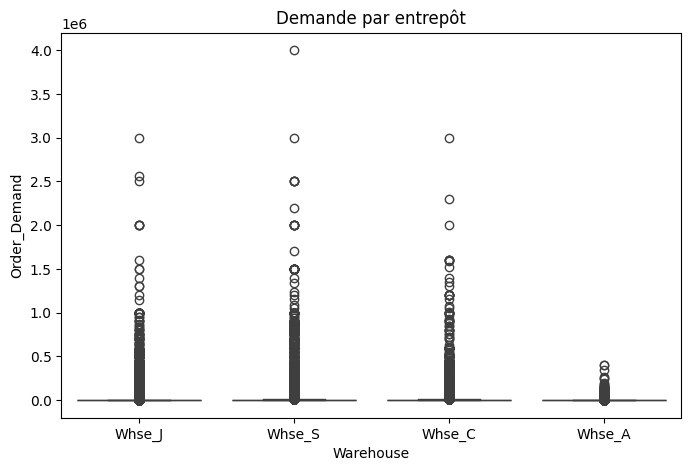

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Warehouse', y='Order_Demand', data=df)
plt.title("Demande par entrepôt")
plt.show()

### Demande par catégorie :     

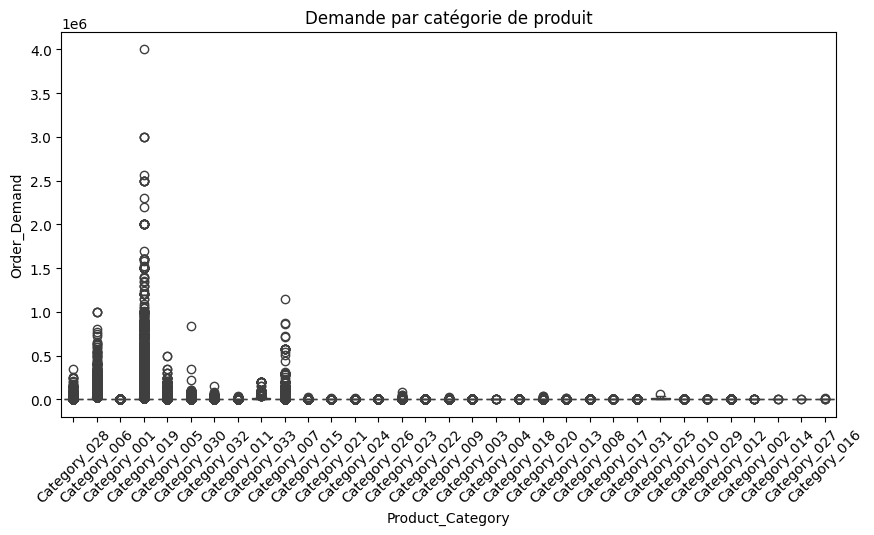

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Product_Category', y='Order_Demand', data=df)
plt.xticks(rotation=45)
plt.title("Demande par catégorie de produit")
plt.show()


### Évolution temporelle   

#### Conversion de la colonne Date en datetime    

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

#### Regroupement par mois et somme des commandes   

In [ ]:
monthly_demand = df.groupby(pd.Grouper(key='Date', freq='MS'))['Order_Demand'].sum()

#### Visualisation de l’évolution mensuelle       

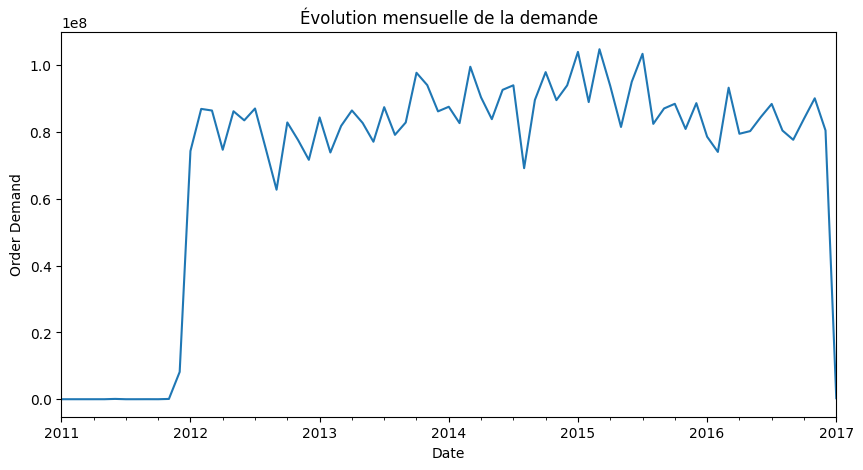

In [ ]:
plt.figure(figsize=(10,5))
monthly_demand.plot()
plt.title("Évolution mensuelle de la demande")
plt.ylabel("Order Demand")
plt.xlabel("Date")
plt.show()


# PRÉTRAITEMENT DES DONNÉES

### Gestion des valeurs manquantes  

#### Suppression des lignes manquantes

In [ ]:
df = df.dropna(subset=[ 'Date' ])

#### Test des valeurs manquantes

In [ ]:
df.isnull().sum()

,0
Product_Code,0
Warehouse,0
Product_Category,0
Date,0
Order_Demand,0


### Encodage des variables catégorielles  

#### One-Hot Encoding   

In [ ]:
df = df.drop(columns=['Product_Code'])
df = pd.get_dummies(
    df,
    columns=['Warehouse', 'Product_Category'],
    drop_first=True
)

#### Convertir les bool en 0/1      

In [ ]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [ ]:
df

,Date,Order_Demand,Warehouse_Whse_C,Warehouse_Whse_J,Warehouse_Whse_S,Product_Category_Category_002,Product_Category_Category_003,Product_Category_Category_004,Product_Category_Category_005,Product_Category_Category_006,...,Product_Category_Category_024,Product_Category_Category_025,Product_Category_Category_026,Product_Category_Category_027,Product_Category_Category_028,Product_Category_Category_029,Product_Category_Category_030,Product_Category_Category_031,Product_Category_Category_032,Product_Category_Category_033
0,2012-07-27,100,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,2012-01-19,500,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,2012-02-03,500,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,2012-02-09,500,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,2012-03-02,500,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,2016-04-27,1000,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1048571,2016-04-27,1,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1048572,2016-04-28,2500,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1048573,2016-10-07,50,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### Création des variables temporelles     

In [ ]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [ ]:
df = df.drop(columns=['Date'])

In [ ]:
df

,Order_Demand,Warehouse_Whse_C,Warehouse_Whse_J,Warehouse_Whse_S,Product_Category_Category_002,Product_Category_Category_003,Product_Category_Category_004,Product_Category_Category_005,Product_Category_Category_006,Product_Category_Category_007,...,Product_Category_Category_027,Product_Category_Category_028,Product_Category_Category_029,Product_Category_Category_030,Product_Category_Category_031,Product_Category_Category_032,Product_Category_Category_033,Year,Month,Day
0,100,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,2012,7,27
1,500,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,2012,1,19
2,500,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,2012,2,3
3,500,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,2012,2,9
4,500,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,2012,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,1000,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,2016,4,27
1048571,1,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,2016,4,27
1048572,2500,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,2016,4,28
1048573,50,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,2016,10,7


### NORMALISATION (Min‑Max)    

#### Séparation X / y

In [ ]:
y = df['Order_Demand']
X = df.drop(columns=['Order_Demand'])

#### Colonnes à Normaliser     

In [ ]:
num_cols = ['Year', 'Month', 'Day']

#### Normalisation appliquée à X

In [ ]:
scaler = MinMaxScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

In [ ]:
X

,Warehouse_Whse_C,Warehouse_Whse_J,Warehouse_Whse_S,Product_Category_Category_002,Product_Category_Category_003,Product_Category_Category_004,Product_Category_Category_005,Product_Category_Category_006,Product_Category_Category_007,Product_Category_Category_008,...,Product_Category_Category_027,Product_Category_Category_028,Product_Category_Category_029,Product_Category_Category_030,Product_Category_Category_031,Product_Category_Category_032,Product_Category_Category_033,Year,Month,Day
0,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0.166667,0.545455,0.866667
1,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0.166667,0.000000,0.600000
2,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0.166667,0.090909,0.066667
3,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0.166667,0.090909,0.266667
4,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0.166667,0.181818,0.033333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,0,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0.833333,0.272727,0.866667
1048571,0,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0.833333,0.272727,0.866667
1048572,0,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0.833333,0.272727,0.900000
1048573,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.833333,0.818182,0.200000


### Séparation Train / Test   

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Modèles du Machine Learning  

### Random Forest Regressor

#### importation   

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

#### Nuage de points  

Text(0.5, 1.0, 'Random Forest ')

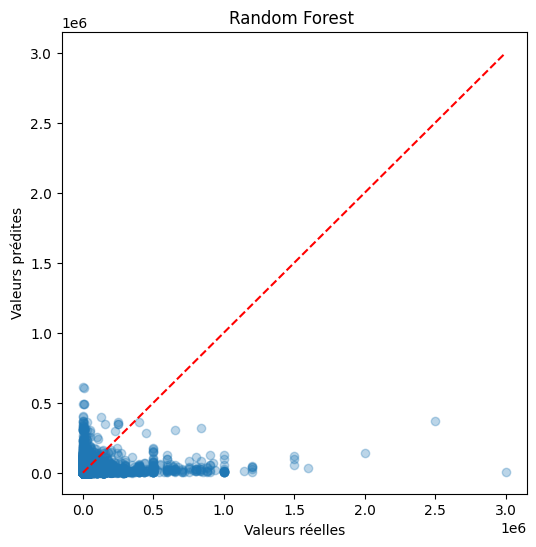

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Random Forest ")

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor")
print("MAE  :", rf_mae)
print("RMSE :", rf_rmse)
print("R²   :", rf_r2)

Random Forest Regressor
MAE  : 6097.33063580123
RMSE : 27839.153821598262
R²   : 0.021042934660292945


# Extra Trees Regressor

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor

etr = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

etr.fit(X_train, y_train)
y_pred_etr = etr.predict(X_test)

### Nuage de points      

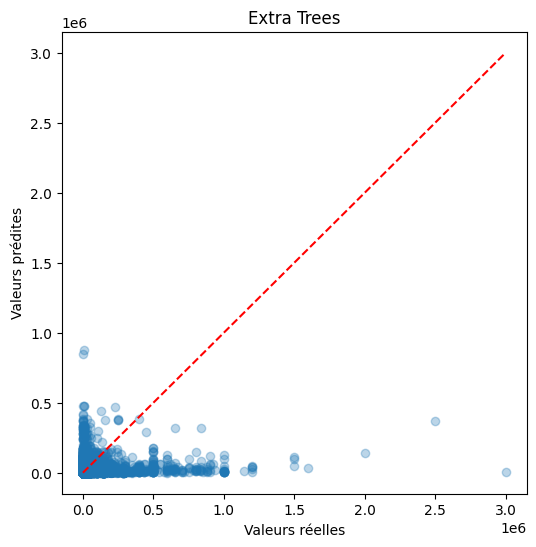

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_etr, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Extra Trees")
plt.show()


In [ ]:
etr_mae = mean_absolute_error(y_test, y_pred_etr)
etr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_etr))
etr_r2 = r2_score(y_test, y_pred_etr)

print("Extra Trees Regressor")
print("MAE  :", etr_mae)
print("RMSE :", etr_rmse)
print("R²   :", etr_r2)

Extra Trees Regressor
MAE  : 6106.455912731764
RMSE : 27975.544939850468
R²   : 0.011427116121791037


# Gradient Boosting Regressor

### Modèle  

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

### Nuage de points   

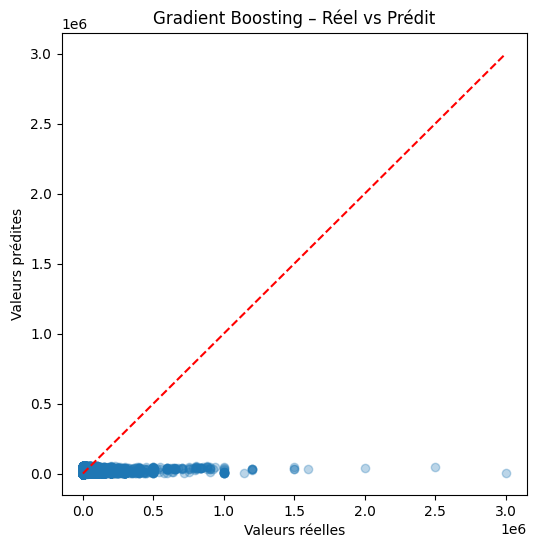

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_gbr, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Gradient Boosting – Réel vs Prédit")
plt.show()


In [ ]:
gbr_mae = mean_absolute_error(y_test, y_pred_gbr)
gbr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
gbr_r2 = r2_score(y_test, y_pred_gbr)

print("Gradient Boosting Regressor")
print("MAE  :", gbr_mae)
print("RMSE :", gbr_rmse)
print("R²   :", gbr_r2)


Gradient Boosting Regressor
MAE  : 6139.422981148746
RMSE : 27199.06627880167
R²   : 0.0655424560157416


In [ ]:
import joblib
joblib.dump(gbr, 'mon_modele.pkl')

['mon_modele.pkl']

In [ ]:
pip install streamlit joblib scikit-learn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 62.5 MB/s eta 0:00:00


In [127]:
import pandas as pd
import joblib
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from google.colab import files

# 1. Chargement avec le nom de ton image + Gestion des erreurs de lignes
filename = 'Historical Product Demand.csv'

try:
    # On ajoute 'on_bad_lines' pour ignorer les lignes avec trop de colonnes
    df = pd.read_csv(filename, on_bad_lines='skip', low_memory=False)
    df.dropna(inplace=True)

    # Nettoyage des parenthèses ( ) dans la colonne Order_Demand
    df['Order_Demand'] = df['Order_Demand'].astype(str).str.replace(r'[\(\)]', '', regex=True)
    df['Order_Demand'] = pd.to_numeric(df['Order_Demand'], errors='coerce')
    df.dropna(subset=['Order_Demand'], inplace=True)

    print(f"✅ Fichier chargé ! {len(df)} lignes prêtes pour l'entraînement.")

    # 2. Encodage des catégories
    le_prod = LabelEncoder().fit(df['Product_Code'])
    le_whse = LabelEncoder().fit(df['Warehouse'])
    le_cat = LabelEncoder().fit(df['Product_Category'])

    df['Product_Code'] = le_prod.transform(df['Product_Code'])
    df['Warehouse'] = le_whse.transform(df['Warehouse'])
    df['Product_Category'] = le_cat.transform(df['Product_Category'])

    # 3. Entraînement rapide du modèle
    X = df[['Product_Code', 'Warehouse', 'Product_Category']]
    y = df['Order_Demand']
    gbr = GradientBoostingRegressor().fit(X, y)

    # 4. Sauvegarde des fichiers .pkl
    joblib.dump(gbr, 'model_gbr.pkl')
    joblib.dump(le_prod, 'encoder_product.pkl')
    joblib.dump(le_whse, 'encoder_warehouse.pkl')
    joblib.dump(le_cat, 'encoder_category.pkl')

    print("🚀 GÉNIAL ! Les 4 fichiers vont être téléchargés sur ton PC...")

    # 5. Téléchargement automatique
    for f in ['model_gbr.pkl', 'encoder_product.pkl', 'encoder_warehouse.pkl', 'encoder_category.pkl']:
        files.download(f)

except Exception as e:
    print(f"❌ Erreur critique : {e}")

✅ Fichier chargé ! 951246 lignes prêtes pour l'entraînement.
🚀 GÉNIAL ! Les 4 fichiers vont être téléchargés sur ton PC...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [128]:
from sklearn.ensemble import RandomForestRegressor
import joblib
from google.colab import files

# Entraînement du 2ème modèle
rf_model = RandomForestRegressor().fit(X, y)

# Sauvegarde sous un nouveau nom
joblib.dump(rf_model, 'model_rf.pkl')

# Téléchargement
files.download('model_rf.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>